In [27]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [28]:
class InitialState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    
    run_rate: float
    boundries_percentage: float
    boundries_runs: float

    summary: str   

In [29]:
def calculate_run_rate(state: InitialState):
    runs = state["runs"]
    balls = state["balls"]
    if balls == 0:
        return {"run_rate": 0.0}

    run_rate = runs / (balls / 6)

    return {
        "run_rate": round(run_rate, 2)
    }

In [30]:
def calculate_boundaries(state: InitialState):
    fours = state["fours"]
    sixes = state["sixes"]

    boundary_runs = (fours * 4) + (sixes * 6)

    return {
        "boundries_runs": float(boundary_runs)
    }

In [31]:
def calculate_boundary_percentage(state: InitialState):
    runs = state["runs"]
    fours = state["fours"]
    sixes = state["sixes"]

    boundary_runs = (fours * 4) + (sixes * 6)

    if runs == 0:
        return {
            "boundries_percentage": 0.0
        }

    percentage = (boundary_runs / runs) * 100

    return {
        "boundries_percentage": round(percentage, 2)
    }

In [32]:
def prepare_summary(state: InitialState):
    return {
       "summary": (
            f"The cricketer scored {state['runs']} runs "
            f"from {state['balls']} balls with "
            f"{state['fours']} fours and {state['sixes']} sixes. "
            f"Run rate was {state['run_rate']}, "
            f"with {state['boundries_runs']} boundary runs "
            f"({state['boundries_percentage']}% of total runs)."
        )
    }

In [33]:
graph = StateGraph(InitialState)

graph.add_node("calculate_run_rate", calculate_run_rate)
graph.add_node("calculate_boundaries", calculate_boundaries)
graph.add_node("calculate_boundary_percentage", calculate_boundary_percentage)
graph.add_node("prepare_summary", prepare_summary)

graph.add_edge(START, "calculate_run_rate")
graph.add_edge(START, "calculate_boundaries")
graph.add_edge(START, "calculate_boundary_percentage")

graph.add_edge("calculate_run_rate", "prepare_summary")
graph.add_edge("calculate_boundaries", "prepare_summary")
graph.add_edge("calculate_boundary_percentage", "prepare_summary")

graph.add_edge("prepare_summary",END)

workflow = graph.compile()

In [34]:
inital = {"runs": 85,
    "balls": 52,
    "fours": 7,
    "sixes": 3}
output = workflow.invoke(inital)
print(output["summary"])

The cricketer scored 85 runs from 52 balls with 7 fours and 3 sixes. Run rate was 9.81, with 46.0 boundary runs (54.12% of total runs).


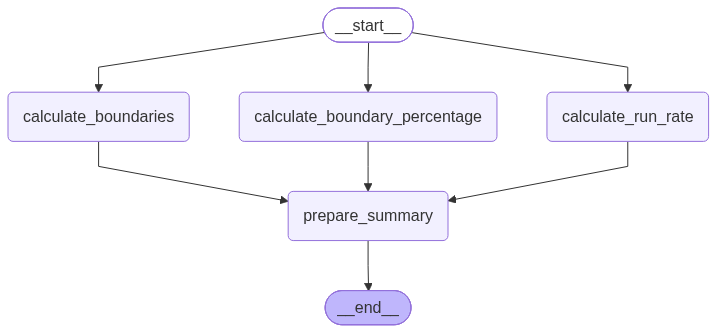

In [35]:
from IPython.display import display, Image

display(
    Image(workflow.get_graph().draw_mermaid_png())
)